In [3]:
import pandas as pd
import krippendorff
from irrCAC.raw import CAC
import seaborn as sns

### Consistency Post Processing

In [4]:
SAMPLE_SIZE = 272
df = pd.read_csv(f'../data/consistency_grades_{SAMPLE_SIZE}_sample.csv')
df = df.drop(columns=['Unnamed: 0'])
df['predictions_0'] = pd.Categorical(df['predictions_0'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_1'] = pd.Categorical(df['predictions_1'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_2'] = pd.Categorical(df['predictions_2'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df['predictions_3'] = pd.Categorical(df['predictions_3'], ['F', 'D-', 'D', 'D+', 'C-', 'C', 'C+', 'B-', 'B', 'B+', 'A-', 'A', 'A+', 'A++'], ordered=True)
df.head()

,assignment_number,grade,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3
0,2,A,This is what the rabbit does most of the time ...,public void act(List<Animal> newRabbits)\n ...,This is what the rabbit does most of the time ...,NaN,NaN,NaN,NaN
1,2,A,Increase the age.\nThis could result in the ra...,private void incrementAge()\n {\n ag...,Increase the age.\nThis could result in the ra...,A,A,A,A
2,2,A,Make this rabbit more hungry. This could resul...,private void incrementHunger()\n {\n ...,Make this rabbit more hungry. This could resul...,B+,B+,B+,B+
3,2,A,Look for rabbits adjacent to the current locat...,private Location findFood()\n {\n Fi...,Look for rabbits adjacent to the current locat...,NaN,NaN,NaN,NaN
4,2,A,Check whether or not this rabbit is to give bi...,private void giveBirth(List<Animal> newRabbits...,Check whether or not this rabbit is to give bi...,NaN,NaN,NaN,NaN


In [5]:
df['assignment_number'].unique().shape

(272,)

#### Consistency Calculation per code doc/code pair

In [6]:
def irr_results(df):
    k_df = df[['predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].copy()
    k_df = k_df.dropna()
    k_df['predictions_0'] = k_df['predictions_0'].cat.codes
    k_df['predictions_1'] = k_df['predictions_1'].cat.codes
    k_df['predictions_2'] = k_df['predictions_2'].cat.codes
    k_df['predictions_3'] = k_df['predictions_3'].cat.codes
    k_df = k_df.transpose()

    cac = CAC(k_df.T, 'ordinal')
    ac2 = cac.gwet()['est']['coefficient_value']

    alpha = krippendorff.alpha(k_df.to_numpy(), level_of_measurement='ordinal')

    return f'Krippendorfs Alpha: {alpha}, Gwet Coefficient: {ac2} for SAMPLE size {SAMPLE_SIZE}'

irr_results(df)


'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 272'

In [7]:
df[(df['predictions_0'] != df['predictions_1']) & (df['predictions_1'] != df['predictions_2']) & (df['predictions_2'] != df['predictions_3'])].dropna()

,assignment_number,grade,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3


### Project-Level

In [8]:
def consensus(group):
    consensus_dict = {}
    for grade in group:
        if grade not in consensus_dict:
            consensus_dict[grade] = 1
        else:
            consensus_dict[grade] += 1
    return max(consensus_dict, key=consensus_dict.get)

project_df = df.copy()
project_df = project_df.dropna()
project_df = project_df[['assignment_number', 'predictions_0', 'predictions_1', 'predictions_2', 'predictions_3']].groupby('assignment_number').agg(consensus)
project_df.head()

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,
2,A,A,A,A
6,A,A,A,A
8,A-,A-,A-,A-
9,B+,B+,B+,B+
10,A,A,A,A


In [9]:
irr_results(project_df)

'Krippendorfs Alpha: 1.0, Gwet Coefficient: 1.0 for SAMPLE size 272'

In [10]:
project_df[(project_df['predictions_0'] != project_df['predictions_1']) & (project_df['predictions_1'] != project_df['predictions_2']) & (project_df['predictions_2'] != project_df['predictions_3'])]

,predictions_0,predictions_1,predictions_2,predictions_3
assignment_number,,,,


### Plots

In [11]:
grey = (187/255, 187/255, 187/255)
darkgreen = (51/255, 117/255, 56/255)
teal = (93/255, 168/255, 153/255)
blue = (148/255, 203/255, 236/255)
yellow = (220/255, 205/255, 125/255)
red = (168/255, 96/255, 93/255)
pale_yellow = (164/255, 168/255, 93/255)
sns.set_theme(style="whitegrid")

#### Ungraded Pairs

In [12]:
ungraded_df = df.copy()
ungraded_df['Graded'] = ungraded_df['predictions_0'].apply(lambda x: 'Ungraded' if x is None else 'Graded')
ungraded_df['Graded'] = ungraded_df['Graded'].fillna('Ungraded')
ungraded_df

,assignment_number,grade,query,func_code_string,text,predictions_0,predictions_1,predictions_2,predictions_3,Graded
0,2,A,This is what the rabbit does most of the time ...,public void act(List<Animal> newRabbits)\n ...,This is what the rabbit does most of the time ...,NaN,NaN,NaN,NaN,Ungraded
1,2,A,Increase the age.\nThis could result in the ra...,private void incrementAge()\n {\n ag...,Increase the age.\nThis could result in the ra...,A,A,A,A,Graded
2,2,A,Make this rabbit more hungry. This could resul...,private void incrementHunger()\n {\n ...,Make this rabbit more hungry. This could resul...,B+,B+,B+,B+,Graded
3,2,A,Look for rabbits adjacent to the current locat...,private Location findFood()\n {\n Fi...,Look for rabbits adjacent to the current locat...,NaN,NaN,NaN,NaN,Ungraded
4,2,A,Check whether or not this rabbit is to give bi...,private void giveBirth(List<Animal> newRabbits...,Check whether or not this rabbit is to give bi...,NaN,NaN,NaN,NaN,Ungraded
...,...,...,...,...,...,...,...,...,...,...
31479,675,B+,Return the animal's field.\n@return The animal...,protected Field getField()\n {\n ret...,Return the animal's field.\n@return The animal...,A,A,A,A,Graded
31480,675,B+,Check whether the plant is alive or not.\n@ret...,protected boolean isAlive()\n {\n re...,Check whether the plant is alive or not.\n@ret...,B+,B+,B+,B+,Graded
31481,675,B+,Indicate that the plant is no longer alive.\nI...,protected void setDead()\n {\n alive...,Indicate that the plant is no longer alive.\nI...,A-,A-,A-,A-,Graded
31482,675,B+,Return the plant's location.\n@return The plan...,protected Location getLocation()\n {\n ...,Return the plant's location.\n@return The plan...,A,A,A,A,Graded


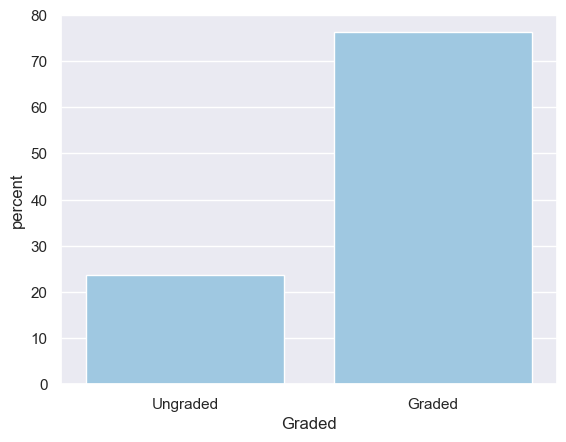

In [13]:
g = sns.countplot(ungraded_df, x='Graded', stat='percent', color=blue)
g.get_figure().savefig(f'plots/ungraded_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')

In [14]:
ungraded_df[ungraded_df['Graded'] == 'Ungraded']['text'].apply(lambda x: len(x)).min()
# Max token length of CodeBERT is 512

512

### Project Grade Plot

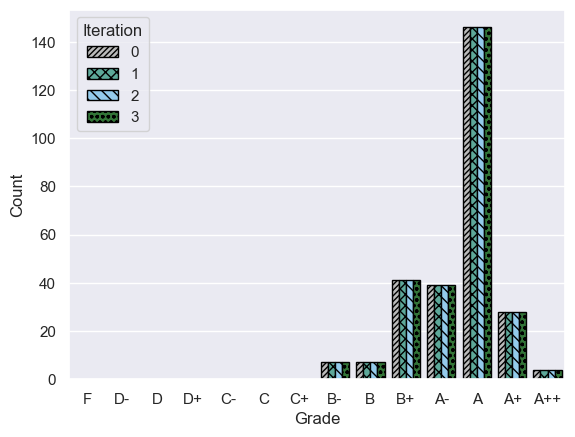

In [15]:
project_plot_df = project_df.copy().reset_index()
project_plot_df.columns = [col[-1] if 'predictions' in col else col for col in project_plot_df.columns]
project_plot_df = project_plot_df.melt(id_vars=['assignment_number'], var_name='predictions_i', value_name='grade')


g = sns.countplot(project_plot_df, x='grade', hue='predictions_i', palette=sns.color_palette([blue, darkgreen, teal, blue]))

hatches = ['//', 'x', '\\', 'o']
colors = [grey, teal, blue, darkgreen]
styles = zip(hatches, colors)


for style, these_bars in zip(styles, g.containers):
    for this_bar in these_bars:
        this_bar.set_hatch(3 * style[0])
        this_bar.set_facecolor(style[1])
        this_bar.set_edgecolor('black')

g.set(xlabel='Grade', ylabel='Count')
handles = g.get_legend_handles_labels()[0]

for i in range(len(handles)):
    handles[i].set_facecolor(colors[i])
    handles[i].set_hatch(3 * hatches[i])
    handles[i].set_edgecolor('black')


g.legend(title='Iteration')
g.get_figure().savefig(f'plots/grade_counts_{SAMPLE_SIZE}.pdf', bbox_inches='tight')